In [39]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns # data visualisation
import matplotlib.pyplot as plt # plot
import os
import warnings

#import funcs
from datetime import datetime
from matplotlib.pyplot import cm

In [41]:
# Some commands
warnings.filterwarnings('ignore')
# color map

In [51]:
df_train = pd.read_csv('Downloads/train.csv', parse_dates=['Date']).set_index(keys=['Store','Dept','Date'], drop=False)
df_train.index.names = ['Store_ind', 'Dept_ind', 'Date_ind']
df_train

Store  Dept       Date  Weekly_Sales  IsHoliday
Store_ind Dept_ind Date_ind                                                   
1         1        2010-02-05      1     1 2010-02-05      24924.50      False
                   2010-02-12      1     1 2010-02-12      46039.49       True
                   2010-02-19      1     1 2010-02-19      41595.55      False
                   2010-02-26      1     1 2010-02-26      19403.54      False
                   2010-03-05      1     1 2010-03-05      21827.90      False
...                              ...   ...        ...           ...        ...
45        98       2012-09-28     45    98 2012-09-28        508.37      False
                   2012-10-05     45    98 2012-10-05        628.10      False
                   2012-10-12     45    98 2012-10-12       1061.02      False
                   2012-10-19     45    98 2012-10-19        760.01      False
                   2012-10-26     45    98 2012-10-26       1076.80      False

[421570 rows x 5 columns]

In [53]:
# Create new features 
df_train['Weekofyear'] = df_train['Date'].dt.isocalendar().week
df_train['Month'] = df_train['Date'].dt.month
df_train['Year'] = df_train['Date'].dt.year

# Calculate the percentage change in weekly sales from one row to the next
df_train['pctchange_Weekly_Sales'] = df_train['Weekly_Sales'].pct_change().fillna(0.)

df_train

Store  Dept       Date  Weekly_Sales  \
Store_ind Dept_ind Date_ind                                           
1         1        2010-02-05      1     1 2010-02-05      24924.50   
                   2010-02-12      1     1 2010-02-12      46039.49   
                   2010-02-19      1     1 2010-02-19      41595.55   
                   2010-02-26      1     1 2010-02-26      19403.54   
                   2010-03-05      1     1 2010-03-05      21827.90   
...                              ...   ...        ...           ...   
45        98       2012-09-28     45    98 2012-09-28        508.37   
                   2012-10-05     45    98 2012-10-05        628.10   
                   2012-10-12     45    98 2012-10-12       1061.02   
                   2012-10-19     45    98 2012-10-19        760.01   
                   2012-10-26     45    98 2012-10-26       1076.80   

                               IsHoliday  Weekofyear  Month  Year  \
Store_ind Dept_ind Date_ind                                         
1         1        2010-02-05      False           5      2  2010   
                   2010-02-12       True           6      2  2010   
                   2010-02-19      False           7      2  2010   
                   2010-02-26      False           8      2  2010   
                   2010-03-05      False           9      3  2010   
...                                  ...         ...    ...   ...   
45        98       2012-09-28      False          39      9  2012   
                   2012-10-05      False          40     10  2012   
                   2012-10-12      False          41     10  2012   
                   2012-10-19      False          42     10  2012   
                   2012-10-26      False          43     10  2012   

                               pctchange_Weekly_Sales  
Store_ind Dept_ind Date_ind                            
1         1        2010-02-05                0.000000  
                   2010-02-12                0.847158  
                   2010-02-19               -0.096525  
                   2010-02-26               -0.533519  
                   2010-03-05                0.124944  
...                                               ...  
45        98       2012-09-28                0.087888  
                   2012-10-05                0.235517  
                   2012-10-12                0.689253  
                   2012-10-19               -0.283699  
                   2012-10-26                0.416823  

[421570 rows x 9 columns]

In [65]:
list_store_dept = [(1,1),(2,2),(3,3),(4,4),(5,5)]

### Generate summary statistics for the Weekly_Sales variable, grouped by each Store–Dept combination. It helps in exploratory data analysis (EDA) to understand how sales behave across different stores and departments ###

In [55]:
Nstore = df_train.index.max()[0] ; Ndept = df_train.index.max()[1]
df_stats = pd.concat([df_train.groupby(['Store','Dept']).median().Weekly_Sales,
                      df_train.groupby(['Store','Dept']).mean().Weekly_Sales,
                      df_train.groupby(['Store','Dept']).std().Weekly_Sales,
                      df_train.groupby(['Store','Dept']).max().Weekly_Sales, 
                      df_train.groupby(['Store','Dept']).min().Weekly_Sales],
                     axis=1)
df_stats.columns = ['Median', 'Mean', 'Std', 'Max', 'Min']
df_stats['Norm_std'] = df_stats['Std']/(df_stats['Mean']) #np.abs
df_stats['Norm_maxmin'] = (df_stats['Max']-df_stats['Min'])/df_stats['Median']
df_stats = df_stats.sort_values(by=['Norm_std'], axis=0, ascending=False)
df_stats.to_csv('summary_stores_stats.csv')
df_stats.head()

,,Median,Mean,Std,Max,Min,Norm_std,Norm_maxmin
Store,Dept,,,,,,,
9,78,0.00,0.000000,18.215071,12.88,-12.88,inf,inf
21,48,0.00,0.000000,21.170777,14.97,-14.97,inf,inf
16,78,0.00,0.000000,18.215071,12.88,-12.88,inf,inf
11,47,21.00,0.920000,173.372713,396.00,-594.00,188.448601,47.142857
35,49,4.97,0.517544,47.876256,62.37,-326.61,92.506664,78.265594


### This code visualizes the distribution of average weekly sales (Mean) and the normalized standard deviations (Norm_std) for all Store–Dept combinations. It gives insight into: how weekly sales differ across departments and how volatile or stable the sales are relative to their means. ###

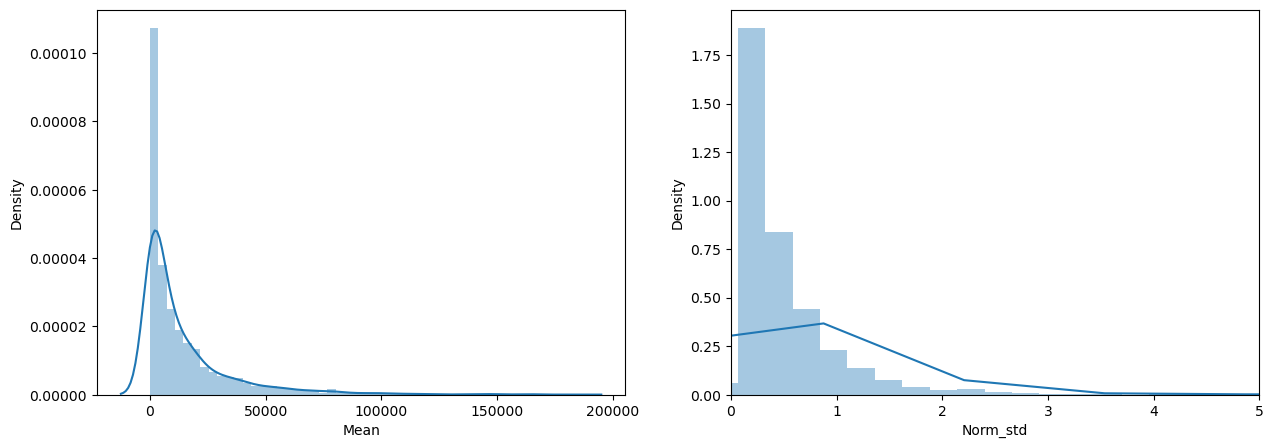

In [57]:
# Distribution of averaged weekly sales and normalised standard deviations
from scipy.stats import norm, skew, probplot #for some statistics
plt.figure(0,figsize=[15,5])
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.subplot(1,2,1)
sns.distplot(df_stats.Mean)#, fit=norm
plt.subplot(1,2,2)
plt.xlim([0,5])
sns.distplot(df_stats.Norm_std.replace([np.inf, -np.inf], np.nan).dropna(),bins=1000)#, fit=norm
plt.show()
plt.close(0)

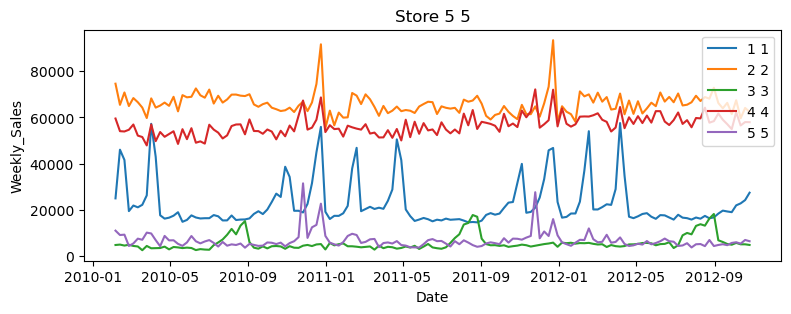

In [67]:
# Plot target feature with time
def plot_target(df, storedept, target, plotname, dpi=100):
    plt.figure(0,figsize=(9,3), dpi=dpi)
    for storedept_tupple in storedept:
        namemag = str(storedept_tupple[0])+' '+str(storedept_tupple[1])
        try:
            df2 = df.loc[storedept_tupple,target]#.drop('Date',axis=1)
            plt.plot(df2.index.to_pydatetime(),df2,label=namemag)# #, color='tab:red')
        except:
            pass
    plt.gca().set(xlabel='Date', ylabel=target, title='Store '+str(storedept_tupple[0])+' '+str(storedept_tupple[1]))
    plt.legend()
    #plt.savefig('figures/'+plotname+'.pdf',bbox_inches='tight',transparent=True)
    plt.show()
    plt.close(0)
    
# plot weekly sale for all departments in individual stores with time
plot_target(df_train,list_store_dept,'Weekly_Sales','sale_store')

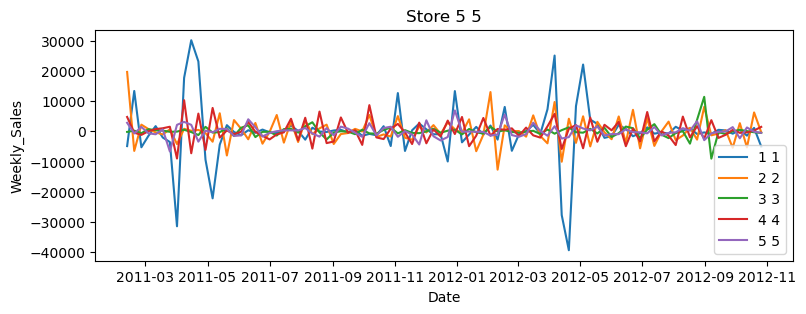

In [71]:
# Differenced weekly sales (e.g., to check trend or seasonality)
def plot_target_diff(df, storedept, list_diff, target, plotname, dpi=100):
    plt.figure(0,figsize=(9,3), dpi=dpi)
    for storedept_tupple in storedept:
        namemag = str(storedept_tupple[0])+' '+str(storedept_tupple[1])
        try:
            df2 = df.loc[storedept_tupple,target]#.drop('Date',axis=1)
            for diff in list_diff:
                df2 = df2.diff(diff)
            plt.plot(df2.index.to_pydatetime(),df2,label=namemag)# #, color='tab:red')
        except:
            pass
    plt.gca().set(xlabel='Date', ylabel=target, title='Store '+str(storedept_tupple[0])+' '+str(storedept_tupple[1]))
    plt.legend()
    #plt.savefig('figures/'+plotname+'.pdf',bbox_inches='tight',transparent=True)
    plt.show()
    plt.close(0)
# plot weekly sale for all departments in individual stores with time
plot_target_diff(df_train,list_store_dept,[1,52],'Weekly_Sales','sale_store')

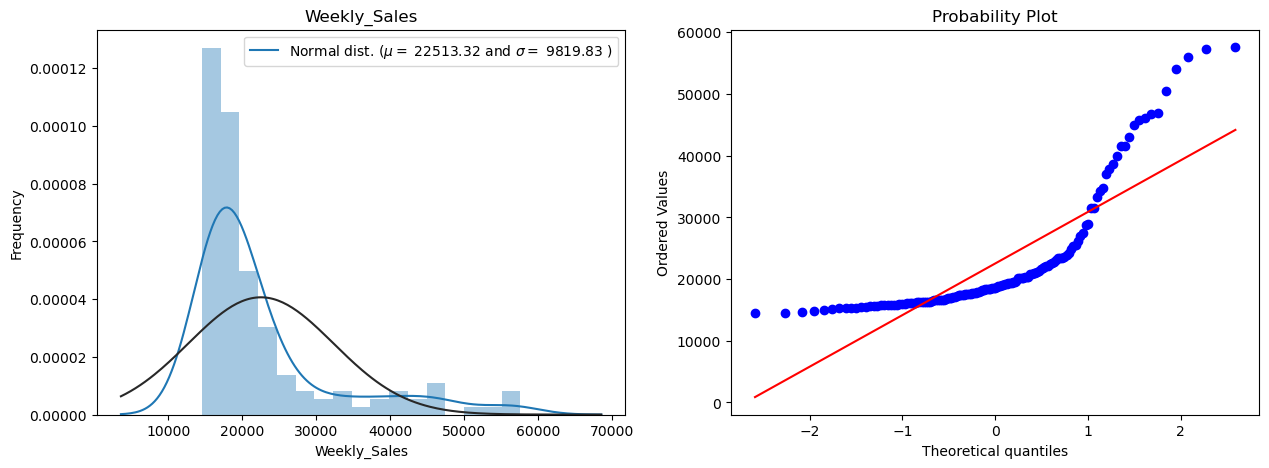

In [73]:
# Distribution of sales for a specific store-department
# Distribution of a typical weekly sales series
def plot_targetdistrib(y,plottitle,plotname):
	from scipy.stats import norm, skew, probplot #for some statistics
	plt.figure(0,figsize=[15,5])
	plt.subplots_adjust(wspace=0.2, hspace=0.5)
	plt.subplot(1,2,1)
	(mu, sigma) = norm.fit(y)
	#print( 'mu = {:.2f} and sigma = {:.2f}'.format(mu, sigma))
	sns.distplot(y, fit=norm)
	plt.legend(['Normal dist. ($\mu=$ {:.2f} and $\sigma=$ {:.2f} )'.format(mu, sigma)],
	            loc='best')
	plt.ylabel('Frequency')
	plt.title(plottitle)
	# QQ-plot wrt normal distribution
	plt.subplot(1,2,2)
	res = probplot(y, plot=plt)
	#plt.savefig('figures/'+plotname+'.pdf',bbox_inches='tight',transparent=True)
	plt.show()
	plt.close(0)
# plot weekly sale distribution for a given department
df2 = df_train.loc[(1,1)]
plot_targetdistrib(df2.Weekly_Sales,'Weekly_Sales','saledistrib1')

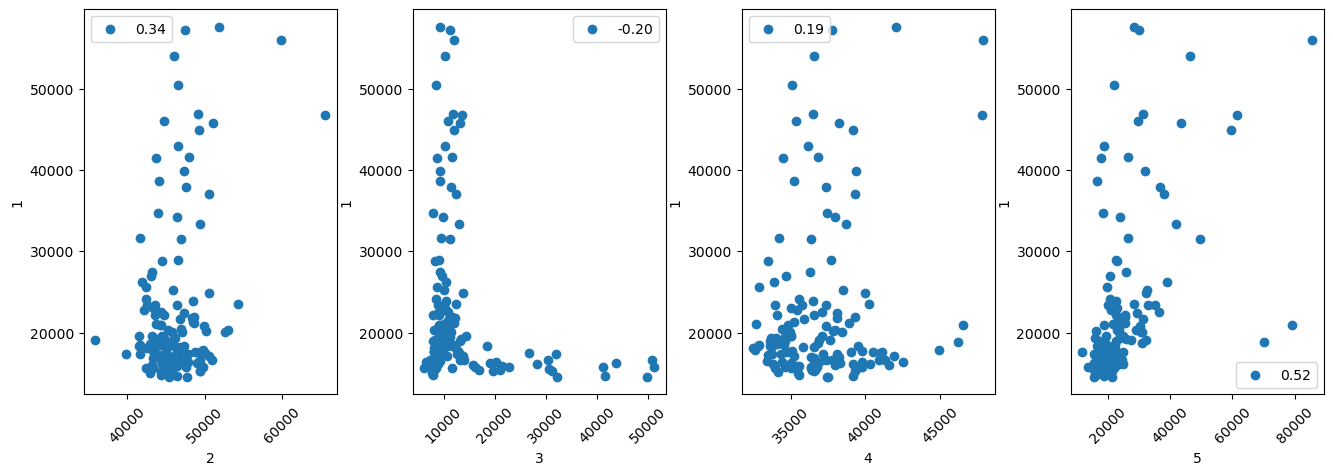

In [75]:
# Correlation of weekly sales across departments in a store
def corr_depts(df, store, list_dept, target, plotname, dpi=100):
    Nstore = df.index.max()[0]
    plt.figure(0,figsize=(16,5), dpi=dpi)
    plt.subplots_adjust(wspace=0.3, hspace=0.5)
    #
    iplot = 1
    for x in (list_dept[1:]):
        plt.subplot(1,len(list_dept)-1,iplot)
        plt.gca().set(xlabel=x, ylabel=list_dept[0])
        plt.xticks(rotation=45)
        try:
            dfx = df.loc[(store,x)].drop('Date',axis=1)[target]
            dfy = df.loc[(store,list_dept[0])].drop('Date',axis=1)[target]
            plt.scatter(dfx, dfy, label=('%.2f' % (dfx.corr(dfy))))# #, color='tab:red')
        except:
            pass
        iplot += 1
        plt.legend()
    #plt.savefig('figures/'+plotname+'.pdf',bbox_inches='tight',transparent=True)
    plt.show()
    plt.close(0)
corr_depts(df_train,1, [1,2,3,4,5],'Weekly_Sales', 'features_vs_weeklysale')